In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.common import random_state

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor


import xgboost as xgb

from sklearn.neural_network import MLPRegressor




In [48]:
df = pd.read_csv('../data/processed/final_genomics_train_data.csv')
df

,Genotype,S1A_687822,S1A_1195489,S1A_1234081,S1A_4781815,S1A_4929734,S1A_5190325,S1A_5548635,S1A_5548650,S1A_5857413,...,SUNKNOWN_336365,SUNKNOWN_336436,SUNKNOWN_336436.1,SUNKNOWN_339127,SUNKNOWN_343096,SUNKNOWN_349202,SUNKNOWN_349202.1,SUNKNOWN_349202.2,SUNKNOWN_349202.3,DON
0,0566A1_3_1_47,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,13.126081
1,0762A1_2_8,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0,1.0,1.0,1.0,1.0,16.491306
2,13VTK59_55,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,-1.0,1,1.0,1.0,1.0,1.0,16.126081
3,Ambassador,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,53.085216
4,CN18_20_2,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,50.526081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,VA17W_75,1,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,-1.0,1,1.0,1.0,1.0,0.0,14.926081
545,X08C_1077_11_18_3,1,1.0,1.0,1.0,-1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,-1,0.0,1.0,-1.0,1.0,22.824640
546,X08_1181_61_15_5,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,18.426081
547,X11_0420_120_13_3,1,-1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,-1.0,1.0,1,1.0,1.0,1.0,1.0,19.626081


In [49]:
y = df[['DON']]
genotypes = df[["Genotype"]]
df.drop(columns=["DON","Genotype"], inplace=True)

In [50]:
print(y.shape)
print(genotypes.shape)
print(df.shape)

(549, 1)
(549, 1)
(549, 15456)


In [51]:
df=df.astype(np.float32)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 549 entries, 0 to 548
Columns: 15456 entries, S1A_687822 to SUNKNOWN_349202.3
dtypes: float32(15456)
memory usage: 32.4 MB


In [52]:
df.head()

,S1A_687822,S1A_1195489,S1A_1234081,S1A_4781815,S1A_4929734,S1A_5190325,S1A_5548635,S1A_5548650,S1A_5857413,S1A_6110098,...,SUNKNOWN_323958,SUNKNOWN_336365,SUNKNOWN_336436,SUNKNOWN_336436.1,SUNKNOWN_339127,SUNKNOWN_343096,SUNKNOWN_349202,SUNKNOWN_349202.1,SUNKNOWN_349202.2,SUNKNOWN_349202.3
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


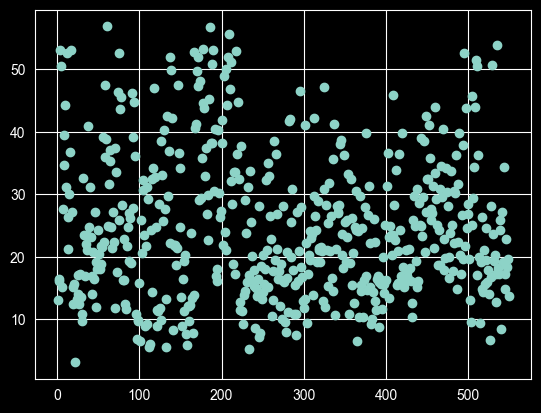

In [68]:
z=y.values.ravel()
z
m = len(df)
plt.scatter(range(1,m+1),z)

In [30]:
X = df


In [32]:
## train test split
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(439, 15456)
(110, 15456)
(439, 1)
(110, 1)


In [42]:
## scaling - even values are scaled
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

print(x_train_scaled.mean())
print(x_test_scaled.var())
print(x_train_scaled[:2])
print(x_test_scaled[:2])

1.7560624e-09
1.0172541
[[ 0.27584064  0.42070538  0.27363974 ...  0.34030303  0.3523894
  -5.5844693 ]
 [ 0.27584064 -2.420674    0.27363974 ...  0.34030303  0.3523894
   0.27355233]]
[[-2.8291345   0.42070538  0.27363974 ...  0.34030303  0.3523894
   0.27355233]
 [ 0.27584064  0.42070538  0.27363974 ...  0.34030303  0.3523894
   0.27355233]]


In [69]:
## Models - Dummy model

In [94]:
dummy_model = LinearRegression()
dummy_model.fit(x_train_scaled, y_train)
y_pred = dummy_model.predict(x_test_scaled)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')


RMSE: 107.8960952758789
R2: 0.3505179286003113
MAE: 7.723753452301025


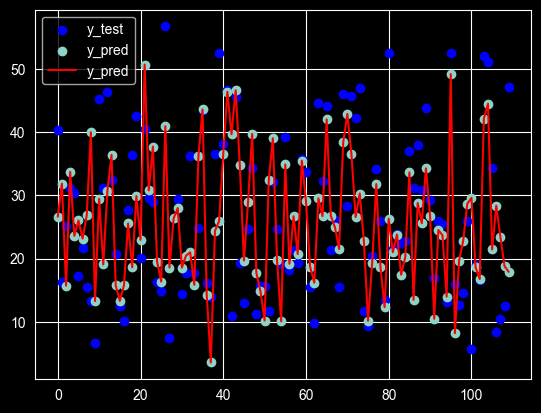

In [97]:
m = len(y_test)
plt.scatter(range(0,m),y_test,label="y_test",color="blue")
plt.scatter(range(0,m),y_pred,label="y_pred")
plt.plot(y_pred,label="y_pred",color="red")
plt.legend()

In [102]:
## Lasso

In [113]:
print(y_test.shape,y_train.shape)
#y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

(110, 1) (439,)


In [114]:
print(y_test.shape,y_train.shape)


(110,) (439,)


In [118]:
sgdlasso = SGDRegressor(penalty="l1", alpha=0.0001, learning_rate='constant', eta0=1e-5)
sgdlasso.fit(x_train_scaled, y_train)
y_pred = sgdlasso.predict(x_test_scaled)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

RMSE: 108.66065555055764
R2: 0.34591567258907185
MAE: 7.775290093728322


In [120]:
sgdridge = SGDRegressor(penalty="l2", alpha=0.0001, learning_rate='constant', eta0=1e-5)
sgdridge.fit(x_train_scaled, y_train)
y_pred = sgdridge.predict(x_test_scaled)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

RMSE: 108.66717596607404
R2: 0.3458764228571807
MAE: 7.772345018558739


In [121]:
## Randomforest

In [123]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(x_train_scaled, y_train)
y_pred = rf_model.predict(x_test_scaled)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

RMSE: 102.2878759877538
R2: 0.3842767078042074
MAE: 7.986628186435181


In [124]:
## Boosting

In [127]:
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1,max_depth=6)
xgb_model.fit(x_train_scaled, y_train)
y_pred = xgb_model.predict(x_test_scaled)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

RMSE: 96.90341696201372
R2: 0.41668853380027115
MAE: 7.663793259929598


In [129]:
## MLP

In [132]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
)

mlp_model.fit(x_train_scaled, y_train)
y_pred = mlp_model.predict(x_test_scaled)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

RMSE: 127.78211715753356
R2: 0.23081376849193103
MAE: 8.758542031920166


## Winner Model is : XGBoost

## Hyper Tuning step

In [139]:
xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5,7],
    'learning_rate': [0.01, 0.05,0.1],
    'subsample': [0.8,1.0],

}
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(x_train_scaled, y_train)
print("Best Parameters found:", grid_search.best_params_)
print("Best CV R2 Score:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best CV R2 Score: 0.3372722346159932


In [146]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(x_test_scaled)

final_r2 = r2_score(y_test, y_pred_tuned)
final_mae = mean_absolute_error(y_test, y_pred_tuned)
final_rmse = mean_squared_error(y_test,y_pred_tuned)

print(f'R2 Score: {final_r2}')
print(f'MAE Score: {final_mae}')
print(f'RMSE score: {final_rmse}')

R2 Score: 0.4031703037987099
MAE Score: 7.696793641256414
RMSE score: 99.14915145265232


## Finding Markers associated with resistance to DON

In [148]:
importances = best_model.feature_importances_

In [153]:
feature_names =X_train.columns
feature_names

Index(['S1A_687822', 'S1A_1195489', 'S1A_1234081', 'S1A_4781815',
       'S1A_4929734', 'S1A_5190325', 'S1A_5548635', 'S1A_5548650',
       'S1A_5857413', 'S1A_6110098',
       ...
       'SUNKNOWN_323958', 'SUNKNOWN_336365', 'SUNKNOWN_336436',
       'SUNKNOWN_336436.1', 'SUNKNOWN_339127', 'SUNKNOWN_343096',
       'SUNKNOWN_349202', 'SUNKNOWN_349202.1', 'SUNKNOWN_349202.2',
       'SUNKNOWN_349202.3'],
      dtype='str', length=15456)

In [155]:
df_importance = pd.DataFrame({
    'SNP_Name': feature_names,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)
df_importance

,SNP_Name,Importance_Score
4429,S2B_725522898,0.035179
11979,S6B_94823837,0.030718
7048,S3B_581770060,0.023541
946,S1B_572977719,0.020067
6303,S3A_706766535,0.018648
...,...,...
404,S1A_512623032,0.000000
15436,SUNKNOWN_269286,0.000000
15437,SUNKNOWN_272138,0.000000
15438,SUNKNOWN_276133,0.000000


In [158]:
mean_importance = df_importance['Importance_Score'].mean()
top_markers = df_importance[df_importance['Importance_Score'] > mean_importance]

top_markers.to_csv('key_resistance_markers.csv', index=False)

In [160]:
top_markers

,SNP_Name,Importance_Score
4429,S2B_725522898,0.035179
11979,S6B_94823837,0.030718
7048,S3B_581770060,0.023541
946,S1B_572977719,0.020067
6303,S3A_706766535,0.018648
...,...,...
3689,S2B_444781581,0.000067
164,S1A_51704282,0.000066
8189,S4A_694152276,0.000066
3485,S2B_238007862,0.000066


In [161]:
print("\n--- Top 10 SNP Markers ---")
print(top_markers.head(10))


--- Top 10 SNP Markers ---
            SNP_Name  Importance_Score
4429   S2B_725522898          0.035179
11979   S6B_94823837          0.030718
7048   S3B_581770060          0.023541
946    S1B_572977719          0.020067
6303   S3A_706766535          0.018648
1024   S1B_620615120          0.018108
8983    S5A_20750635          0.017727
2318   S2A_695403580          0.017248
5992    S3A_57092796          0.017078
2414   S2A_709988140          0.013701


In [163]:
plt.figure(figsize=(10, 5))
plot_data = top_markers.head(10).sort_values(by='Importance_Score', ascending=True)

<Figure size 1000x500 with 0 Axes>

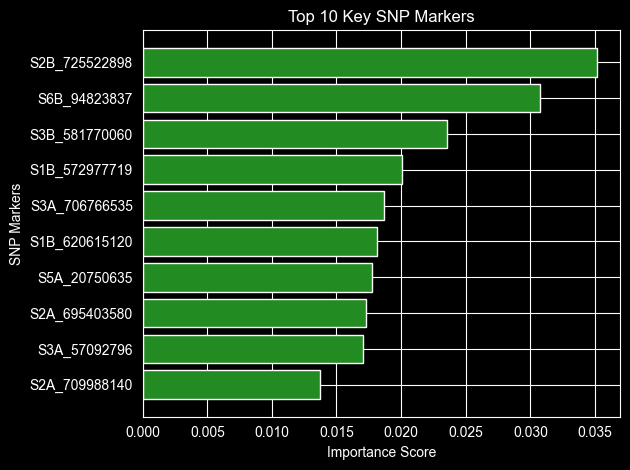

In [164]:
plt.barh(plot_data['SNP_Name'], plot_data['Importance_Score'], color='forestgreen')
plt.xlabel('Importance Score')
plt.ylabel('SNP Markers')
plt.title('Top 10 Key SNP Markers')
plt.tight_layout()
plt.show()